In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import sklearn.cluster as cluster
import sklearn.metrics as metrics

In [ ]:
df = pd.read_excel("data.xlsx")
df

,K,X1,X2,X3,X4,X5,X6
0,1,78.29,10.40,57.55,25.77,16.68,64.79
1,2,61.69,8.67,42.45,46.36,11.19,64.61
2,3,64.36,21.51,49.89,18.33,31.78,63.34
3,4,69.26,9.23,52.12,28.53,19.34,63.76
4,5,44.25,43.86,52.49,17.76,29.75,64.31
5,6,38.29,39.49,58.67,11.79,29.55,60.14
6,7,66.79,14.61,57.73,22.45,19.82,68.13
7,8,37.60,62.40,55.30,23.29,21.41,57.72


In [ ]:
df1 = df.drop(["K"], axis=1)

In [ ]:
df1

,X1,X2,X3,X4,X5,X6
0,78.29,10.40,57.55,25.77,16.68,64.79
1,61.69,8.67,42.45,46.36,11.19,64.61
2,64.36,21.51,49.89,18.33,31.78,63.34
3,69.26,9.23,52.12,28.53,19.34,63.76
4,44.25,43.86,52.49,17.76,29.75,64.31
5,38.29,39.49,58.67,11.79,29.55,60.14
6,66.79,14.61,57.73,22.45,19.82,68.13
7,37.60,62.40,55.30,23.29,21.41,57.72


In [ ]:
multikol = df1.corr()
multikol

,X1,X2,X3,X4,X5,X6
X1,1.000000,-0.904407,-0.147472,0.414607,-0.481165,0.721402
X2,-0.904407,1.000000,0.315456,-0.519310,0.505699,-0.762607
X3,-0.147472,0.315456,1.000000,-0.746761,0.322551,-0.135815
X4,0.414607,-0.519310,-0.746761,1.000000,-0.870413,0.273963
X5,-0.481165,0.505699,0.322551,-0.870413,1.000000,-0.289505
X6,0.721402,-0.762607,-0.135815,0.273963,-0.289505,1.000000


<Axes: >

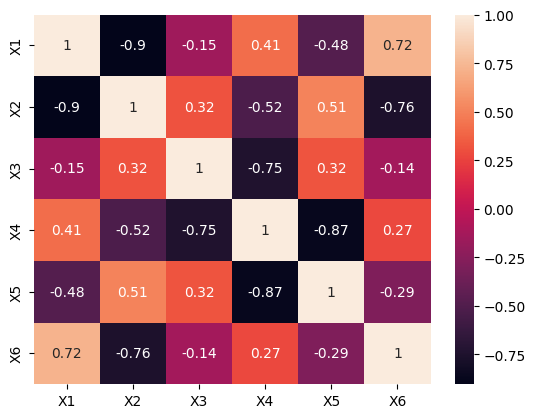

In [ ]:
sns.heatmap(multikol, annot=True)

In [ ]:
K = range(1,7)
wss = []
for k in K:
    kmeans=cluster.KMeans(n_clusters=k,init="k-means++")
    kmeans=kmeans.fit(df)
    wss_iter = kmeans.inertia_
    wss.append(wss_iter)

In [ ]:
mycenters = pd.DataFrame({'Clusters' : K, 'WSS' : wss})
mycenters

,Clusters,WSS
0,1,5890.216875
1,2,1645.340227
2,3,1238.659710
3,4,550.019000
4,5,235.775017
5,6,142.014750


<Axes: xlabel='Clusters', ylabel='WSS'>

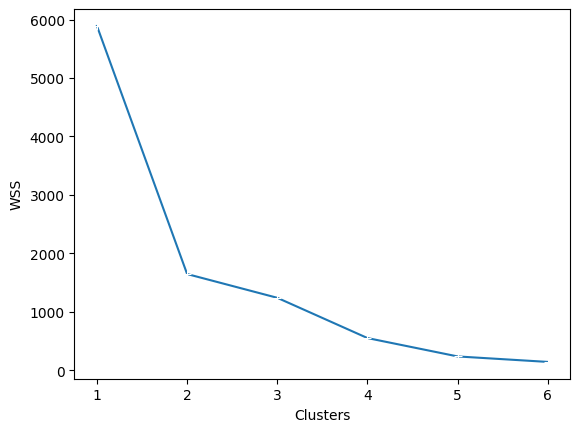

In [ ]:
sns.lineplot(x = 'Clusters', y = 'WSS', data = mycenters, marker="+")

In [ ]:
SK = range(2,7)
sil_score = []
for i in SK:
    labels=cluster.KMeans(n_clusters=i,init="k-means++",random_state=200).fit(df).labels_
    score = metrics.silhouette_score(df,labels,metric="euclidean",sample_size=1000,random_state=200)
    sil_score.append(score)
    print ("Silhouette score for k(clusters) = "+str(i)+" is "
           +str(metrics.silhouette_score(df,labels,metric="euclidean",sample_size=1000,random_state=200)))

Silhouette score for k(clusters) = 2 is 0.5581347260350404
Silhouette score for k(clusters) = 3 is 0.43178444845654745
Silhouette score for k(clusters) = 4 is 0.3381232288507223
Silhouette score for k(clusters) = 5 is 0.21529034146216108
Silhouette score for k(clusters) = 6 is 0.15321654593047904


In [ ]:
sil_centers = pd.DataFrame({'Clusters' : SK, 'Sil Score' : sil_score})
sil_centers

,Clusters,Sil Score
0,2,0.558135
1,3,0.431784
2,4,0.338123
3,5,0.215290
4,6,0.153217


<Axes: xlabel='Clusters', ylabel='Sil Score'>

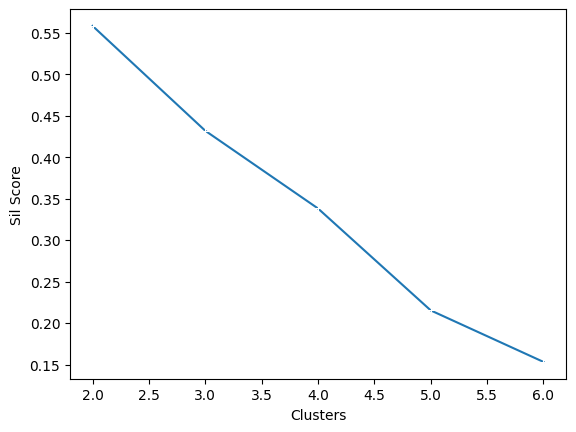

In [ ]:
sns.lineplot(x = 'Clusters', y = 'Sil Score', data = sil_centers, marker="+")

In [ ]:
kmeans = cluster.KMeans(n_clusters=2 ,init="k-means++")
y_kmeans = kmeans.fit(df)

In [ ]:
df['Clusters'] = kmeans.labels_

In [ ]:
df

,K,X1,X2,X3,X4,X5,X6,Clusters
0,1,78.29,10.40,57.55,25.77,16.68,64.79,1
1,2,61.69,8.67,42.45,46.36,11.19,64.61,1
2,3,64.36,21.51,49.89,18.33,31.78,63.34,1
3,4,69.26,9.23,52.12,28.53,19.34,63.76,1
4,5,44.25,43.86,52.49,17.76,29.75,64.31,0
5,6,38.29,39.49,58.67,11.79,29.55,60.14,0
6,7,66.79,14.61,57.73,22.45,19.82,68.13,1
7,8,37.60,62.40,55.30,23.29,21.41,57.72,0


In [ ]:
klaster1 = df[df['Clusters'] == 0]
klaster2 = df[df['Clusters'] == 1]

In [ ]:
klaster1.mean()

,0
K,6.333333
X1,40.046667
X2,48.583333
X3,55.486667
X4,17.613333
X5,26.903333
X6,60.723333
Clusters,0.000000


In [ ]:
klaster2.mean()

,0
K,3.400
X1,68.078
X2,12.884
X3,51.948
X4,28.288
X5,19.762
X6,64.926
Clusters,1.000
